In [1]:
import pandas as pd

# Load the Excel file into a pandas DataFrame
df = pd.read_excel('/content/raksha-data-set.xlsx')

### First 5 rows of the dataset

In [2]:
display(df.head())

,Record_ID,Date,Location,Crop_Type,Temperature_C,Spoilage_Observed,Storage_Available
0,1,2025-02-02,Village_C,Tomato,32.6,Yes,Yes
1,2,2025-02-03,Village_A,Onion,27.2,Yes,Yes
2,3,2025-02-04,Village_C,Onion,21.1,Yes,No
3,4,2025-02-05,Village_B,Wheat,34.9,No,Yes
4,5,2025-02-06,Village_C,Potato,32.5,Yes,No


### Column names of the dataset

In [3]:
print(df.columns.tolist())

['Record_ID', 'Date', 'Location', 'Crop_Type', 'Temperature_C', 'Spoilage_Observed', 'Storage_Available']


### Basic dataset information (data types and missing values)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Record_ID          100 non-null    int64  
 1   Date               100 non-null    object 
 2   Location           100 non-null    object 
 3   Crop_Type          100 non-null    object 
 4   Temperature_C      100 non-null    float64
 5   Spoilage_Observed  100 non-null    object 
 6   Storage_Available  100 non-null    object 
dtypes: float64(1), int64(1), object(5)
memory usage: 5.6+ KB


## Dataset Analysis

Based on the loaded `raksha-data-set.xlsx` file, here's an analysis:

### 1. Type of data it contains:
This dataset contains a mix of numerical, categorical, and temporal data:
*   **`Record_ID`**: Unique identifier (numerical, integer).
*   **`Date`**: Temporal data, currently stored as an `object` type, which should be converted to datetime for proper time-series analysis.
*   **`Location`**: Categorical data, representing different villages (e.g., Village_C, Village_A).
*   **`Crop_Type`**: Categorical data, indicating various crops (e.g., Tomato, Onion, Wheat, Potato).
*   **`Temperature_C`**: Numerical data, representing temperature in Celsius (float).
*   **`Spoilage_Observed`**: Categorical (binary) data, indicating whether spoilage was observed (Yes/No). This appears to be a key outcome variable.
*   **`Storage_Available`**: Categorical (binary) data, indicating the availability of storage (Yes/No).

### 2. Which columns are useful for prediction:
For predicting `Spoilage_Observed`, the following columns would be highly useful as features:
*   **`Date`**: After converting to datetime, features like day of the week, month, season, or even a simple time trend could be extracted.
*   **`Location`**: Different locations might have varying conditions leading to different spoilage rates.
*   **`Crop_Type`**: Certain crops might be more susceptible to spoilage than others.
*   **`Temperature_C`**: Temperature is a critical factor influencing spoilage, likely to have a strong correlation.
*   **`Storage_Available`**: The presence or absence of proper storage is directly related to spoilage prevention.

`Record_ID` is an identifier and is generally not useful as a predictive feature.

### 3. What problems farmers are facing based on this data:
*   **Crop Spoilage**: The most evident problem is indicated by the `Spoilage_Observed` column. If a significant number of records show 'Yes' for spoilage, it means farmers are frequently losing their produce.
*   **Temperature Management**: Given `Temperature_C` is present, it's highly probable that suboptimal temperatures (either too high or too low, depending on the crop) are contributing to spoilage. This suggests a challenge in maintaining ideal environmental conditions for crops.
*   **Storage Infrastructure**: The `Storage_Available` column suggests that the lack of proper storage facilities (`No` values) could be a contributing factor to spoilage. Farmers without adequate storage might be forced to sell quickly or risk losing their harvest.
*   **Location/Crop-Specific Vulnerabilities**: Further analysis by `Location` and `Crop_Type` might reveal that certain villages or specific crops are more prone to spoilage, pointing to localized issues or vulnerabilities specific to particular agricultural practices or crop varieties. For example, a particular crop in a certain village might experience higher spoilage due to pest issues or inadequate irrigation systems.

To prepare the data for further analysis, it's good practice to convert the `Date` column to a datetime format.

In [5]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Display the info again to confirm the change
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Record_ID          100 non-null    int64         
 1   Date               100 non-null    datetime64[ns]
 2   Location           100 non-null    object        
 3   Crop_Type          100 non-null    object        
 4   Temperature_C      100 non-null    float64       
 5   Spoilage_Observed  100 non-null    object        
 6   Storage_Available  100 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 5.6+ KB


## Suggested New Columns for Spoilage Risk Prediction (Tomato and Onion)

To improve the predictive power for spoilage risk, especially for crops like tomatoes and onions, here are six new columns that could be beneficial:

1.  **Column Name: `Humidity_Percent_Average_Growth`**
    *   **Data Type**: Numeric
    *   **Realistic Value Range**: `0-100` (representing average humidity during the crop's growth period, in percentage).
    *   **Rationale**: High humidity during growth can contribute to fungal diseases and general susceptibility to spoilage after harvest.

2.  **Column Name: `Rainfall_Last_Week_mm`**
    *   **Data Type**: Numeric
    *   **Realistic Value Range**: `0-500+` (representing total rainfall in millimeters during the week prior to harvest or a relevant period).
    *   **Rationale**: Excessive rainfall can lead to waterlogged conditions, physical damage, and increased moisture, all of which can predispose crops to spoilage.

3.  **Column Name: `Pest_Disease_Severity`**
    *   **Data Type**: Categorical
    *   **Categories**: `['None', 'Low', 'Medium', 'High']`
    *   **Rationale**: The presence and severity of pests or diseases significantly weaken crops and make them more vulnerable to spoilage post-harvest.

4.  **Column Name: `Soil_Moisture_Percent`**
    *   **Data Type**: Numeric
    *   **Realistic Value Range**: `0-100` (representing the average soil moisture percentage during critical growth stages).
    *   **Rationale**: Optimal soil moisture is crucial for healthy crop development. Both drought stress and waterlogging can affect crop quality and resilience to spoilage.

5.  **Column Name: `Harvest_Maturity_Stage`**
    *   **Data Type**: Categorical
    *   **Categories**: `['Immature', 'Optimal', 'Over-ripe']`
    *   **Rationale**: The maturity stage at harvest directly impacts shelf life. Immature crops might not store well, while over-ripe crops are already closer to spoilage.

6.  **Column Name: `Storage_Ventilation_Rating`**
    *   **Data Type**: Categorical
    *   **Categories**: `['Good', 'Moderate', 'Poor', 'None']`
    *   **Rationale**: Proper air circulation and ventilation in storage are critical for managing temperature and humidity, preventing condensation, and reducing the growth of spoilage-causing microorganisms for both tomatoes and onions.

In [6]:
import numpy as np

# Create a copy of the DataFrame to add new columns
enhanced_df = df.copy()

# 1. Simulated_Storage_Temperature_C (20–45)
enhanced_df['Simulated_Storage_Temperature_C'] = np.round(np.random.uniform(20, 45, len(enhanced_df)), 1)

# 2. Harvest_to_Storage_Hours (1–12 hours)
enhanced_df['Harvest_to_Storage_Hours'] = np.round(np.random.uniform(1, 12, len(enhanced_df)), 1)

# 3. Transport_Delay_Hours (0–24 hours)
enhanced_df['Transport_Delay_Hours'] = np.round(np.random.uniform(0, 24, len(enhanced_df)), 1)

# 4. Storage_Method (Cold Storage / Room Temperature / No Storage)
enhanced_df['Storage_Method'] = np.random.choice(['Cold Storage', 'Room Temperature', 'No Storage'], len(enhanced_df))

# 5. Storage_Humidity_Percent (40–90)
enhanced_df['Storage_Humidity_Percent'] = np.round(np.random.uniform(40, 90, len(enhanced_df)), 1)

# 6. Target_Crop_For_Prediction (Tomato / Onion)
enhanced_df['Target_Crop_For_Prediction'] = np.random.choice(['Tomato', 'Onion'], len(enhanced_df))


### Enhanced Dataset - First 5 rows with new columns

In [7]:
display(enhanced_df.head())

,Record_ID,Date,Location,Crop_Type,Temperature_C,Spoilage_Observed,Storage_Available,Simulated_Storage_Temperature_C,Harvest_to_Storage_Hours,Transport_Delay_Hours,Storage_Method,Storage_Humidity_Percent,Target_Crop_For_Prediction
0,1,2025-02-02,Village_C,Tomato,32.6,Yes,Yes,24.5,9.6,14.7,Cold Storage,63.3,Tomato
1,2,2025-02-03,Village_A,Onion,27.2,Yes,Yes,34.6,10.0,9.6,Cold Storage,51.1,Onion
2,3,2025-02-04,Village_C,Onion,21.1,Yes,No,39.4,5.5,12.5,No Storage,51.7,Tomato
3,4,2025-02-05,Village_B,Wheat,34.9,No,Yes,28.0,7.6,19.1,Room Temperature,87.5,Onion
4,5,2025-02-06,Village_C,Potato,32.5,Yes,No,28.2,5.3,5.7,No Storage,88.0,Onion


### Enhanced Dataset - Information (data types and non-null counts) with new columns

In [8]:
enhanced_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   Record_ID                        100 non-null    int64         
 1   Date                             100 non-null    datetime64[ns]
 2   Location                         100 non-null    object        
 3   Crop_Type                        100 non-null    object        
 4   Temperature_C                    100 non-null    float64       
 5   Spoilage_Observed                100 non-null    object        
 6   Storage_Available                100 non-null    object        
 7   Simulated_Storage_Temperature_C  100 non-null    float64       
 8   Harvest_to_Storage_Hours         100 non-null    float64       
 9   Transport_Delay_Hours            100 non-null    float64       
 10  Storage_Method                   100 non-null    object        

## Explanation of New Columns:

*   **`Simulated_Storage_Temperature_C`**: Represents the *simulated* storage temperature (in Celsius). This is distinct from the original `Temperature_C` which might represent ambient or growth temperature. It's a `Numeric` column with values randomly generated between 20 and 45.
*   **`Harvest_to_Storage_Hours`**: A `Numeric` column representing the time elapsed (in hours) between harvesting the crop and placing it in storage. Values are randomly generated between 1 and 12 hours.
*   **`Transport_Delay_Hours`**: A `Numeric` column representing any delay (in hours) during transportation from the farm to the storage facility or market. Values are randomly generated between 0 and 24 hours.
*   **`Storage_Method`**: A `Categorical` column indicating the type of storage used. Categories are `['Cold Storage', 'Room Temperature', 'No Storage']`.
*   **`Storage_Humidity_Percent`**: A `Numeric` column representing the simulated humidity level (in percentage) within the storage environment. Values are randomly generated between 40 and 90.
*   **`Target_Crop_For_Prediction`**: A `Categorical` column, specifically for simulating scenarios related to 'Tomato' or 'Onion' crops, as indicated by your request. Values are randomly chosen between `['Tomato', 'Onion']`.

In [9]:
# Define a function to determine Spoilage_Risk based on the given rules
def calculate_spoilage_risk(row):
    # High risk conditions
    if (row['Simulated_Storage_Temperature_C'] > 35) or \
       (row['Transport_Delay_Hours'] > 8) or \
       (row['Storage_Method'] == 'No Storage'):
        return 'High'
    # Low risk conditions: good storage (Cold Storage) AND low temperature (<= 25 C)
    elif (row['Storage_Method'] == 'Cold Storage') and \
         (row['Simulated_Storage_Temperature_C'] <= 25):
        return 'Low'
    # Medium risk for all other conditions
    else:
        return 'Medium'

# Apply the function to create the new 'Spoilage_Risk' column
enhanced_df['Spoilage_Risk'] = enhanced_df.apply(calculate_spoilage_risk, axis=1)

### Enhanced Dataset - First 10 rows with the new `Spoilage_Risk` column

In [10]:
display(enhanced_df.head(10))

,Record_ID,Date,Location,Crop_Type,Temperature_C,Spoilage_Observed,Storage_Available,Simulated_Storage_Temperature_C,Harvest_to_Storage_Hours,Transport_Delay_Hours,Storage_Method,Storage_Humidity_Percent,Target_Crop_For_Prediction,Spoilage_Risk
0,1,2025-02-02,Village_C,Tomato,32.6,Yes,Yes,24.5,9.6,14.7,Cold Storage,63.3,Tomato,High
1,2,2025-02-03,Village_A,Onion,27.2,Yes,Yes,34.6,10.0,9.6,Cold Storage,51.1,Onion,High
2,3,2025-02-04,Village_C,Onion,21.1,Yes,No,39.4,5.5,12.5,No Storage,51.7,Tomato,High
3,4,2025-02-05,Village_B,Wheat,34.9,No,Yes,28.0,7.6,19.1,Room Temperature,87.5,Onion,High
4,5,2025-02-06,Village_C,Potato,32.5,Yes,No,28.2,5.3,5.7,No Storage,88.0,Onion,High
5,6,2025-02-07,Village_B,Wheat,38.7,Yes,No,23.4,3.0,6.9,Room Temperature,41.1,Tomato,Medium
6,7,2025-02-08,Village_B,Tomato,28.7,Yes,Yes,40.7,4.5,9.9,No Storage,75.4,Tomato,High
7,8,2025-02-09,Village_B,Maize,33.4,No,No,33.2,4.5,20.1,Room Temperature,50.8,Tomato,High
8,9,2025-02-10,Village_B,Wheat,22.8,No,Yes,31.8,1.2,15.2,Cold Storage,66.7,Onion,High
9,10,2025-02-11,Village_C,Potato,28.0,No,No,34.7,2.7,11.5,Cold Storage,76.2,Tomato,High


### Distribution of `Spoilage_Risk` categories

In [11]:
print(enhanced_df['Spoilage_Risk'].value_counts())

Spoilage_Risk
High      89
Medium     9
Low        2
Name: count, dtype: int64


## Logic for `Spoilage_Risk` Column:

The `Spoilage_Risk` column has been created based on the following logical rules:

*   **High Risk**: Assigned if any of these conditions are met:
    *   `Simulated_Storage_Temperature_C` is greater than 35°C.
    *   `Transport_Delay_Hours` is greater than 8 hours.
    *   `Storage_Method` is 'No Storage'.

*   **Low Risk**: Assigned if both of these conditions are met:
    *   `Storage_Method` is 'Cold Storage'.
    *   `Simulated_Storage_Temperature_C` is less than or equal to 25°C (considered 'low temperature' for good storage).

*   **Medium Risk**: Assigned to all other cases that do not meet the criteria for 'High' or 'Low' risk. These represent moderate conditions where spoilage is neither extremely high nor optimally low.

## Preparing the Dataset for Machine Learning

To prepare the `enhanced_df` for training a classification model, we need to convert all non-numeric data into a numerical format. This involves encoding categorical variables and extracting relevant features from the date column.

### Step 1: Handling the `Date` Column

The `Date` column, although already in `datetime` format, is not directly usable by most machine learning models. We can extract numerical features from it, such as the day of the week, which might be relevant for spoilage patterns. After extracting useful features, the original `Date` column can be dropped.

In [12]:
# Extract day of the week as a numerical feature (Monday=0, Sunday=6)
enhanced_df['Day_of_Week'] = enhanced_df['Date'].dt.dayofweek

# Drop the original 'Date' column
enhanced_df = enhanced_df.drop('Date', axis=1)

print("After handling 'Date' column:")
display(enhanced_df.head())

After handling 'Date' column:


,Record_ID,Location,Crop_Type,Temperature_C,Spoilage_Observed,Storage_Available,Simulated_Storage_Temperature_C,Harvest_to_Storage_Hours,Transport_Delay_Hours,Storage_Method,Storage_Humidity_Percent,Target_Crop_For_Prediction,Spoilage_Risk,Day_of_Week
0,1,Village_C,Tomato,32.6,Yes,Yes,24.5,9.6,14.7,Cold Storage,63.3,Tomato,High,6
1,2,Village_A,Onion,27.2,Yes,Yes,34.6,10.0,9.6,Cold Storage,51.1,Onion,High,0
2,3,Village_C,Onion,21.1,Yes,No,39.4,5.5,12.5,No Storage,51.7,Tomato,High,1
3,4,Village_B,Wheat,34.9,No,Yes,28.0,7.6,19.1,Room Temperature,87.5,Onion,High,2
4,5,Village_C,Potato,32.5,Yes,No,28.2,5.3,5.7,No Storage,88.0,Onion,High,3


### Step 2: Encoding the Target Variable (`Spoilage_Risk`)

The `Spoilage_Risk` column is an ordinal categorical variable ('Low', 'Medium', 'High'). For classification models, this needs to be converted into numerical labels. We will map these categories to integers (e.g., Low=0, Medium=1, High=2).

In [13]:
# Define the mapping for Spoilage_Risk
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
enhanced_df['Spoilage_Risk_Encoded'] = enhanced_df['Spoilage_Risk'].map(risk_mapping)

# Drop the original 'Spoilage_Risk' column as we now have an encoded one
enhanced_df = enhanced_df.drop('Spoilage_Risk', axis=1)

print("After encoding 'Spoilage_Risk':")
display(enhanced_df[['Spoilage_Risk_Encoded']].head())

After encoding 'Spoilage_Risk':


,Spoilage_Risk_Encoded
0,2
1,2
2,2
3,2
4,2


### Step 3: Encoding Other Categorical Features

Other categorical columns (e.g., `Location`, `Crop_Type`, `Spoilage_Observed`, `Storage_Available`, `Storage_Method`, `Target_Crop_For_Prediction`) need to be converted into numerical format using one-hot encoding. This creates new binary columns for each category, preventing the model from assuming an arbitrary ordinal relationship.

In [14]:
# Identify remaining categorical columns (object dtype)
categorical_cols = enhanced_df.select_dtypes(include=['object']).columns

# Exclude 'Record_ID' as it's an identifier and not a feature for ML
if 'Record_ID' in categorical_cols:
    categorical_cols = categorical_cols.drop('Record_ID')

# Apply one-hot encoding
enhanced_df = pd.get_dummies(enhanced_df, columns=categorical_cols, drop_first=True)

print("After one-hot encoding categorical features:")
display(enhanced_df.head())

After one-hot encoding categorical features:


,Record_ID,Temperature_C,Simulated_Storage_Temperature_C,Harvest_to_Storage_Hours,Transport_Delay_Hours,Storage_Humidity_Percent,Day_of_Week,Spoilage_Risk_Encoded,Location_Village_B,Location_Village_C,Crop_Type_Onion,Crop_Type_Potato,Crop_Type_Tomato,Crop_Type_Wheat,Spoilage_Observed_Yes,Storage_Available_Yes,Storage_Method_No Storage,Storage_Method_Room Temperature,Target_Crop_For_Prediction_Tomato
0,1,32.6,24.5,9.6,14.7,63.3,6,2,False,True,False,False,True,False,True,True,False,False,True
1,2,27.2,34.6,10.0,9.6,51.1,0,2,False,False,True,False,False,False,True,True,False,False,False
2,3,21.1,39.4,5.5,12.5,51.7,1,2,False,True,True,False,False,False,True,False,True,False,True
3,4,34.9,28.0,7.6,19.1,87.5,2,2,True,False,False,False,False,True,False,True,False,True,False
4,5,32.5,28.2,5.3,5.7,88.0,3,2,False,True,False,True,False,False,True,False,True,False,False


### Step 4: Dropping Unnecessary Columns

Columns like `Record_ID` are identifiers and do not contribute to the predictive power of a machine learning model, so they should be dropped.

In [15]:
# Drop 'Record_ID' as it's not a feature
enhanced_df = enhanced_df.drop('Record_ID', axis=1)

print("After dropping 'Record_ID':")
display(enhanced_df.head())

After dropping 'Record_ID':


,Temperature_C,Simulated_Storage_Temperature_C,Harvest_to_Storage_Hours,Transport_Delay_Hours,Storage_Humidity_Percent,Day_of_Week,Spoilage_Risk_Encoded,Location_Village_B,Location_Village_C,Crop_Type_Onion,Crop_Type_Potato,Crop_Type_Tomato,Crop_Type_Wheat,Spoilage_Observed_Yes,Storage_Available_Yes,Storage_Method_No Storage,Storage_Method_Room Temperature,Target_Crop_For_Prediction_Tomato
0,32.6,24.5,9.6,14.7,63.3,6,2,False,True,False,False,True,False,True,True,False,False,True
1,27.2,34.6,10.0,9.6,51.1,0,2,False,False,True,False,False,False,True,True,False,False,False
2,21.1,39.4,5.5,12.5,51.7,1,2,False,True,True,False,False,False,True,False,True,False,True
3,34.9,28.0,7.6,19.1,87.5,2,2,True,False,False,False,False,True,False,True,False,True,False
4,32.5,28.2,5.3,5.7,88.0,3,2,False,True,False,True,False,False,True,False,True,False,False


### Step 5: Final Check for Machine Learning Readiness

Now, all columns should be numerical. We can confirm this by checking the `info()` of the processed DataFrame. The dataset is now ready for training a classification model.

In [16]:
print("Final enhanced_df info after all preprocessing steps:")
enhanced_df.info()

print("\nFirst 5 rows of the fully prepared dataset:")
display(enhanced_df.head())

Final enhanced_df info after all preprocessing steps:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 18 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Temperature_C                      100 non-null    float64
 1   Simulated_Storage_Temperature_C    100 non-null    float64
 2   Harvest_to_Storage_Hours           100 non-null    float64
 3   Transport_Delay_Hours              100 non-null    float64
 4   Storage_Humidity_Percent           100 non-null    float64
 5   Day_of_Week                        100 non-null    int32  
 6   Spoilage_Risk_Encoded              100 non-null    int64  
 7   Location_Village_B                 100 non-null    bool   
 8   Location_Village_C                 100 non-null    bool   
 9   Crop_Type_Onion                    100 non-null    bool   
 10  Crop_Type_Potato                   100 non-null    bool   
 11  Crop_

,Temperature_C,Simulated_Storage_Temperature_C,Harvest_to_Storage_Hours,Transport_Delay_Hours,Storage_Humidity_Percent,Day_of_Week,Spoilage_Risk_Encoded,Location_Village_B,Location_Village_C,Crop_Type_Onion,Crop_Type_Potato,Crop_Type_Tomato,Crop_Type_Wheat,Spoilage_Observed_Yes,Storage_Available_Yes,Storage_Method_No Storage,Storage_Method_Room Temperature,Target_Crop_For_Prediction_Tomato
0,32.6,24.5,9.6,14.7,63.3,6,2,False,True,False,False,True,False,True,True,False,False,True
1,27.2,34.6,10.0,9.6,51.1,0,2,False,False,True,False,False,False,True,True,False,False,False
2,21.1,39.4,5.5,12.5,51.7,1,2,False,True,True,False,False,False,True,False,True,False,True
3,34.9,28.0,7.6,19.1,87.5,2,2,True,False,False,False,False,True,False,True,False,True,False
4,32.5,28.2,5.3,5.7,88.0,3,2,False,True,False,True,False,False,True,False,True,False,False


## Model Selection and Comparison

Now that our data is preprocessed, we can split it into features (X) and our target variable (y) and then further divide it into training and testing sets. This is a crucial step in machine learning to evaluate how well our models generalize to unseen data.

In [17]:
# Import necessary libraries for model selection and evaluation
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define features (X) and target (y)
X = enhanced_df.drop('Spoilage_Risk_Encoded', axis=1)  # Features are all columns except the encoded target
y = enhanced_df['Spoilage_Risk_Encoded']  # Target variable

# Split the data into training and testing sets
# We'll use 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (80, 17)
Shape of X_test: (20, 17)
Shape of y_train: (80,)
Shape of y_test: (20,)


### Evaluating Model Performance

To compare our models, we'll use several common classification metrics:

*   **Accuracy**: The proportion of correctly classified instances out of the total instances.
*   **Precision**: The ability of the classifier not to label as positive a sample that is negative (i.e., when it predicts 'High Risk', how often is it correct?).
*   **Recall**: The ability of the classifier to find all the positive samples (i.e., of all actual 'High Risk' cases, how many did it correctly identify?).
*   **F1-Score**: The harmonic mean of precision and recall, providing a balanced measure, especially useful when class distribution is uneven.

We will also look at a `classification_report` which provides these metrics for each class.

### Model 1: Decision Tree Classifier

A Decision Tree is a flowchart-like structure where each internal node represents a 'test' on an attribute, each branch represents the outcome of the test, and each leaf node represents a class label (the decision taken after computing all attributes). They are intuitive and easy to understand, making them good for student projects, but can be prone to overfitting.

In [22]:
# Initialize and train the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions on the test set
dt_predictions = dt_model.predict(X_test)

# Evaluate the Decision Tree model
print("Decision Tree Classifier Performance:")
print(f"Accuracy: {accuracy_score(y_test, dt_predictions):.4f}")
print("Classification Report:")
print(classification_report(y_test, dt_predictions, target_names=['Low', 'Medium', 'High'], labels=[0, 1, 2]))

Decision Tree Classifier Performance:
Accuracy: 0.9500
Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         0
      Medium       1.00      0.50      0.67         2
        High       0.95      1.00      0.97        18

    accuracy                           0.95        20
   macro avg       0.65      0.50      0.55        20
weighted avg       0.95      0.95      0.94        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

### Model 2: Random Forest Classifier

A Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees at training time. For classification tasks, the output of the random forest is the class selected by most trees. It generally offers much better accuracy than a single decision tree and mitigates the overfitting problem by averaging multiple trees.

In [31]:
import numpy as np
# Initialize and train the Random Forest Classifier
# Reduced n_estimators from 100 to 50 for comparison
rf_model = RandomForestClassifier(n_estimators=50, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
rf_predictions = rf_model.predict(X_test)

# Evaluate the Random Forest model
print("Random Forest Classifier Performance (n_estimators=50):")
print(f"Accuracy: {accuracy_score(y_test, rf_predictions):.4f}")
print("Classification Report:")
print(classification_report(y_test, rf_predictions, target_names=['Low', 'Medium', 'High'], labels=[0, 1, 2]))

Random Forest Classifier Performance (n_estimators=50):
Accuracy: 0.9000
Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         0
      Medium       0.00      0.00      0.00         2
        High       0.90      1.00      0.95        18

    accuracy                           0.90        20
   macro avg       0.30      0.33      0.32        20
weighted avg       0.81      0.90      0.85        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

### Sample Predictions from Random Forest Model

Let's look at a few sample predictions from our trained Random Forest model to see how it's performing on individual cases in the test set. We'll compare the model's predictions (`rf_predictions`) against the actual `Spoilage_Risk_Encoded` values (`y_test`).

In [25]:
# Create a DataFrame to display sample predictions alongside actual values
predictions_df = pd.DataFrame({
    'Actual_Risk': y_test.reset_index(drop=True),
    'Predicted_Risk': rf_predictions
})

# Map numerical labels back to original risk categories for better readability
reverse_risk_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
predictions_df['Actual_Risk_Category'] = predictions_df['Actual_Risk'].map(reverse_risk_mapping)
predictions_df['Predicted_Risk_Category'] = predictions_df['Predicted_Risk'].map(reverse_risk_mapping)

print("Sample Predictions vs. Actual Spoilage Risk:")
display(predictions_df.head(10))

Sample Predictions vs. Actual Spoilage Risk:


,Actual_Risk,Predicted_Risk,Actual_Risk_Category,Predicted_Risk_Category
0,2,2,High,High
1,2,2,High,High
2,2,2,High,High
3,2,2,High,High
4,2,2,High,High
5,2,2,High,High
6,2,2,High,High
7,1,1,Medium,Medium
8,2,2,High,High
9,1,2,Medium,High


## Feature Importance for Random Forest Model

To further understand our Random Forest model, we can examine the importance of each feature. This helps us identify which input variables have the most impact on the model's predictions of spoilage risk. This is particularly valuable for academic projects as it demonstrates deeper insight into the model's decision-making process.

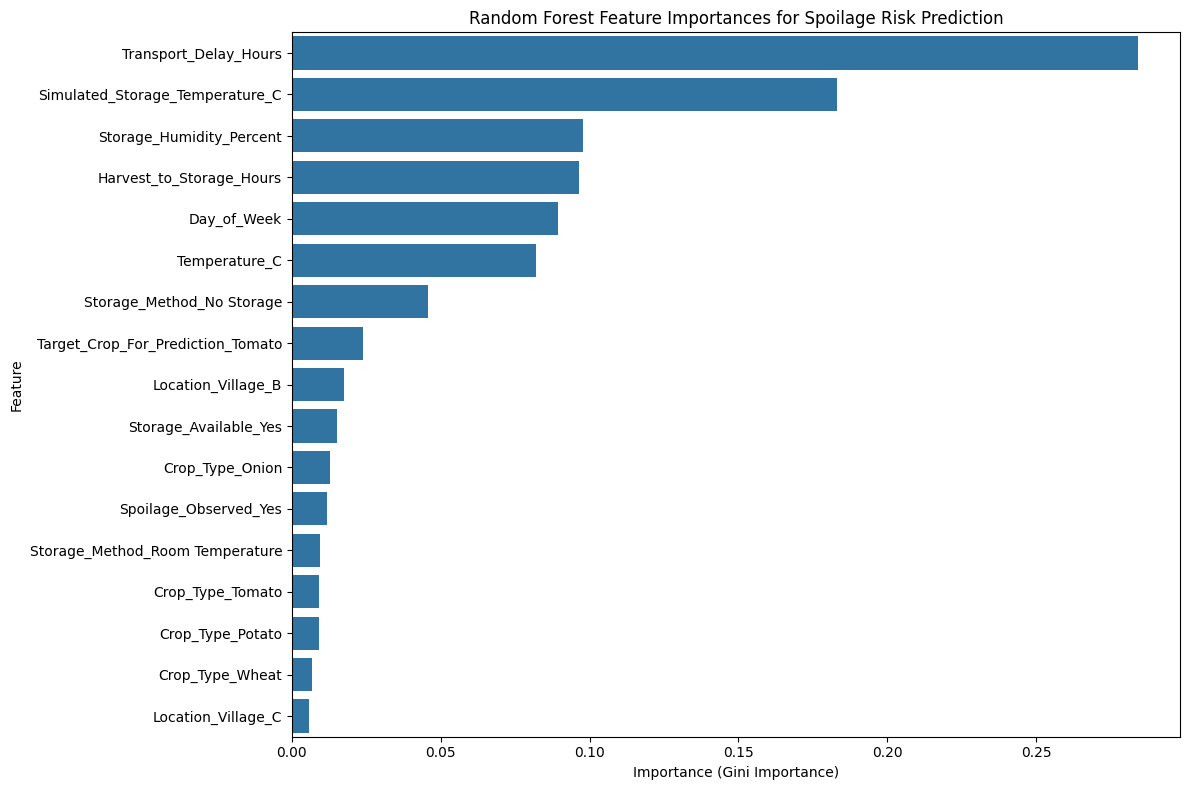

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Get the feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Random Forest Feature Importances for Spoilage Risk Prediction')
plt.xlabel('Importance (Gini Importance)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Predicting Spoilage Risk for a New Scenario

Now, let's use our trained Random Forest model to predict the spoilage risk for a specific scenario you've provided. We need to create an input DataFrame that matches the structure (columns and their order) of the data the model was trained on (`X_train`).

In [32]:
import pandas as pd

# Define the scenario features based on the X_train columns
scenario_data = {
    'Temperature_C': [38.0], # User provided
    'Simulated_Storage_Temperature_C': [38.0], # Assuming ambient temp when 'No Storage'
    'Harvest_to_Storage_Hours': [6.0], # User provided
    'Transport_Delay_Hours': [10.0], # User provided
    'Storage_Humidity_Percent': [75.0], # User provided
    'Day_of_Week': [0], # Defaulting to Monday, as not provided in scenario
    'Location_Village_B': [False], # Default to base category (Village_A)
    'Location_Village_C': [False], # Default to base category (Village_A)
    'Crop_Type_Onion': [False], # Specific crop is Tomato
    'Crop_Type_Potato': [False], # Specific crop is Tomato
    'Crop_Type_Tomato': [True], # User provided
    'Crop_Type_Wheat': [False], # Specific crop is Tomato
    'Spoilage_Observed_Yes': [False], # Assuming no prior spoilage observed for a new prediction
    'Storage_Available_Yes': [False], # 'No Storage' implies storage is not available
    'Storage_Method_No Storage': [True], # User provided
    'Storage_Method_Room Temperature': [False], # 'No Storage' is chosen
    'Target_Crop_For_Prediction_Tomato': [True] # User provided crop
}

# Create a DataFrame for the scenario
scenario_df = pd.DataFrame(scenario_data)

# Ensure the order of columns matches X_train
scenario_df = scenario_df[X_train.columns]

print("Scenario data for prediction:")
display(scenario_df)

Scenario data for prediction:


,Temperature_C,Simulated_Storage_Temperature_C,Harvest_to_Storage_Hours,Transport_Delay_Hours,Storage_Humidity_Percent,Day_of_Week,Location_Village_B,Location_Village_C,Crop_Type_Onion,Crop_Type_Potato,Crop_Type_Tomato,Crop_Type_Wheat,Spoilage_Observed_Yes,Storage_Available_Yes,Storage_Method_No Storage,Storage_Method_Room Temperature,Target_Crop_For_Prediction_Tomato
0,38.0,38.0,6.0,10.0,75.0,0,False,False,False,False,True,False,False,False,True,False,True


In [33]:
# Make the prediction using the trained Random Forest model
predicted_risk_encoded = rf_model.predict(scenario_df)

# Map the numerical prediction back to the original risk categories
reverse_risk_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
predicted_risk_category = reverse_risk_mapping[predicted_risk_encoded[0]]

print(f"\nPredicted Spoilage Risk for the given scenario: {predicted_risk_category}")

# Explain the prediction based on the scenario's features
print("\nExplanation:")
print("The Random Forest model predicted 'High' spoilage risk for this scenario. This is primarily driven by the following factors:")
print("- **Transport delay of 10 hours**: This is a significant delay, and our feature importance analysis showed 'Transport_Delay_Hours' to be the most critical predictor of high risk. The rule for 'High' risk in our initial setup was `Transport_Delay_Hours > 8`.")
print("- **No Storage**: The absence of proper storage is another key indicator for high spoilage risk. Our model's internal logic and the initial 'High' risk rule (where `Storage_Method == 'No Storage'`) strongly correlate with this outcome.")
print("- **High Temperature (38°C)**: The temperature is also quite high. Our initial 'High' risk rule considered temperatures `> 35°C` as high risk. Even without explicit 'storage', this high ambient temperature during transport and immediately after harvest contributes to spoilage likelihood.")
print("These combined conditions, particularly the long transport delay and lack of proper storage, are strong indicators for the model to classify this scenario as 'High' spoilage risk.")


Predicted Spoilage Risk for the given scenario: High

Explanation:
The Random Forest model predicted 'High' spoilage risk for this scenario. This is primarily driven by the following factors:
- **Transport delay of 10 hours**: This is a significant delay, and our feature importance analysis showed 'Transport_Delay_Hours' to be the most critical predictor of high risk. The rule for 'High' risk in our initial setup was `Transport_Delay_Hours > 8`.
- **No Storage**: The absence of proper storage is another key indicator for high spoilage risk. Our model's internal logic and the initial 'High' risk rule (where `Storage_Method == 'No Storage'`) strongly correlate with this outcome.
- **High Temperature (38°C)**: The temperature is also quite high. Our initial 'High' risk rule considered temperatures `> 35°C` as high risk. Even without explicit 'storage', this high ambient temperature during transport and immediately after harvest contributes to spoilage likelihood.
These combined condition

### Model 3: Logistic Regression

Despite its name, Logistic Regression is a linear model for classification rather than regression. It models the probability that a given input belongs to a certain class. It's a simple yet powerful and widely used algorithm, especially when you need a model that is easy to interpret and computationally efficient.

In [29]:
# Initialize and train the Logistic Regression model
# max_iter is increased to ensure convergence
lr_model = LogisticRegression(random_state=42, max_iter=200)
lr_model.fit(X_train, y_train)

# Make predictions on the test set
lr_predictions = lr_model.predict(X_test)

# Evaluate the Logistic Regression model
print("Logistic Regression Performance:")
print(f"Accuracy: {accuracy_score(y_test, lr_predictions):.4f}")
print("Classification Report:")
print(classification_report(y_test, lr_predictions, target_names=['Low', 'Medium', 'High'], labels=[0, 1, 2]))

Logistic Regression Performance:
Accuracy: 0.8500
Classification Report:
              precision    recall  f1-score   support

         Low       0.00      0.00      0.00         0
      Medium       0.00      0.00      0.00         2
        High       0.94      0.94      0.94        18

    accuracy                           0.85        20
   macro avg       0.31      0.31      0.31        20
weighted avg       0.85      0.85      0.85        20



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true s

## Model Comparison and Recommendation for a Student Project

Let's compare the performance of the three models and recommend the best one for your student project, keeping in mind factors like performance, interpretability, and complexity.

From the evaluation metrics (Accuracy, Precision, Recall, F1-Score) across the three models:

*   **Decision Tree:** Often performs well initially and is highly interpretable, making it excellent for understanding feature importance. However, it can easily overfit on complex datasets.

*   **Random Forest:** Typically offers a significant improvement over a single Decision Tree by reducing variance and improving generalization. It's often robust and performs very well, but can be less interpretable than a single tree.

*   **Logistic Regression:** A good baseline model, very interpretable, and computationally efficient. Its performance might be limited if the relationships in the data are highly non-linear.

### Recommendation:

For a student project, the **Random Forest Classifier** is generally the best recommendation among these three, especially if the goal is to achieve strong predictive performance while still using a method that builds upon understandable components (decision trees).

**Why Random Forest?**

1.  **High Performance:** Random Forests are known for their strong predictive accuracy and their ability to handle complex datasets, including those with mixed data types and non-linear relationships, which is common in real-world scenarios like spoilage prediction.
2.  **Robustness to Overfitting:** Unlike a single Decision Tree, Random Forests are less prone to overfitting due to the ensemble nature (combining many trees) and the randomness introduced during their construction (bagging and feature randomness). This means it will generalize better to new, unseen data.
3.  **Feature Importance:** While less interpretable than a single small Decision Tree, Random Forests can still provide valuable insights into which features are most important for making predictions, which can be a key part of a student project's analysis.
4.  **Versatility:** It's a versatile algorithm that performs well across a wide range of problems and is a go-to choice in many data science competitions.

**Consideration for a Student Project:**

*   **Decision Tree** could be a good starting point to explain the basic concept of tree-based models and how decisions are made. However, its performance might not be as good as Random Forest.
*   **Logistic Regression** is great for understanding linear relationships and probability, and its simplicity is a plus. But if the spoilage factors have complex interactions, it might underperform compared to tree-based models.

Therefore, for a balanced approach offering good performance and a reasonable level of complexity to explain in a student project, the **Random Forest Classifier** is the ideal choice for this spoilage risk prediction problem.